# Alignment of volume stacks

## Alignment using Kornia
Kornia uses GPU acceleration and intensity-based global optimization between image pairs

In [ ]:
from pathlib import Path
import torch
import kornia
import tifffile
import matplotlib.pyplot as plt

In [ ]:
def load_image(path: Path) -> torch.Tensor:
    """Load image to floating point tensor"""
    img = tifffile.imread(path)
    tensor = kornia.image_to_tensor(img, keepdim=False).float()
    return tensor


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

path_img_fixed = Path("../data/raw/Au_01-vol_01/Au_01-vol_01-z_0837.tif")
path_img_moving = Path("../data/raw/Au_01-vol_01/Au_01-vol_01-z_0838.tif")

img_fixed = load_image(path_img_fixed).to(device)
img_moving = load_image(path_img_moving).to(device)

registrator = kornia.geometry.ImageRegistrator(
    model_type=kornia.geometry.Similarity(scale=False).to(device),
    loss_fn=torch.nn.functional.mse_loss,
    warper=kornia.geometry.HomographyWarper,
).to(device)

transformation = registrator.register(
    img_fixed,
    img_moving,
    verbose=True,
)

In [46]:
with torch.no_grad():
    img_out = kornia.geometry.homography_warp(
        img_moving, transformation, img_fixed.shape[-2::]
    )
    img_out = img_out.detach().cpu().numpy().squeeze()

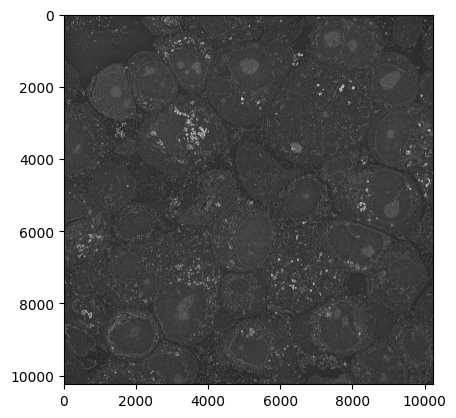

In [49]:
fig, ax = plt.subplots()
ax.imshow(img_out, cmap="gray")